<a href="https://colab.research.google.com/github/lucioquildrian/Challenge-Alura_Telecomx2/blob/main/Telecomx_LATAM_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Preparación de los Datos

In [3]:
import pandas as pd

# 1. Cargamos el dataset limpio de la Parte 1
df_telecom = pd.read_csv('telecom_limpio.csv')

# 2. Pegamos una mirada rápida para comprobar que todo esté en orden
print("--- 📊 VISTAZO AL DATASET LIMPIO ---")
display(df_telecom.head())

# 3. Revisamos que no haya quedado ningún nulo colgado y chequeamos los tipos de datos
print("\n--- 🛠️ INFO DEL DATASET ---")
df_telecom.info()

--- 📊 VISTAZO AL DATASET LIMPIO ---


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Factura_Digital,Metodo_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Total_Servicios
0,0002-ORFBO,0.0,Femenino,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,3
1,0003-MKNFE,0.0,Masculino,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,1
2,0004-TLHLJ,1.0,Masculino,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,1.0,Masculino,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,4
4,0013-EXCHZ,1.0,Femenino,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,2



--- 🛠️ INFO DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Tiene_Pareja            7267 non-null   object 
 5   Tiene_Dependientes      7267 non-null   object 
 6   Meses_Contrato          7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   object 
 8   Multiples_Lineas        7267 non-null   object 
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   object 
 11  Respaldo_Online         7267 non-null   object 
 12  Proteccion_Dispositivo  7267 non-null   object 
 13  Soporte_Tecnico         7267 non-null   object 
 14  TV_Streamin

In [4]:
# 1. Eliminamos la columna de identificación usando el método .drop()
df_telecom = df_telecom.drop('ID_Cliente', axis=1)

# 2. Comprobamos que ya no esté en nuestra tabla
print("--- 🗑️ DATASET SIN COLUMNAS IRRELEVANTES ---")
display(df_telecom.head(3))

--- 🗑️ DATASET SIN COLUMNAS IRRELEVANTES ---


,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,...,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Factura_Digital,Metodo_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Total_Servicios
0,0.0,Femenino,0,Yes,Yes,9,Yes,No,DSL,No,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,3
1,0.0,Masculino,0,No,No,9,Yes,Yes,DSL,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,1
2,1.0,Masculino,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1


In [5]:
# 1. Aplicamos One-Hot Encoding
df_modelos = pd.get_dummies(df_telecom, drop_first=True, dtype=int)

# 2. Comparamos cómo creció nuestra tabla
print("--- 🔄 TRANSFORMACIÓN ONE-HOT ENCODING ---")
print(f"Columnas antes del encoding: {df_telecom.shape[1]}")
print(f"Columnas después del encoding: {df_modelos.shape[1]}\n")

# 3. Vemos el resultado final
display(df_modelos.head(3))

--- 🔄 TRANSFORMACIÓN ONE-HOT ENCODING ---
Columnas antes del encoding: 22
Columnas después del encoding: 33



,Evasion,Adulto_Mayor,Meses_Contrato,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Total_Servicios,Genero_Masculino,Tiene_Pareja_Yes,Tiene_Dependientes_Yes,...,TV_Streaming_No internet service,TV_Streaming_Yes,Peliculas_Streaming_No internet service,Peliculas_Streaming_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Factura_Digital_Yes,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0.0,0,9,65.6,593.30,2.19,3,0,1,1,...,0,1,0,0,1,0,1,0,0,1
1,0.0,0,9,59.9,542.40,2.00,1,1,0,0,...,0,0,0,1,0,0,0,0,0,1
2,1.0,0,4,73.9,280.85,2.46,1,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [10]:
# 1. Vemos la cantidad exacta de clientes en cada grupo
print("\n--- 📊 RECUENTO DE CLASES (Absoluto) ---")
print(df_modelos['Evasion'].value_counts())

# 2. Vemos la proporción en porcentaje usando normalize=True
print("\n--- ⚖️ PROPORCIÓN DE CLASES (Porcentajes) ---")
proporcion = df_modelos['Evasion'].value_counts(normalize=True) * 100
print(proporcion.round(2).astype(str) + '%')


--- 📊 RECUENTO DE CLASES (Absoluto) ---
Evasion
0.0    5163
1.0    1869
Name: count, dtype: int64

--- ⚖️ PROPORCIÓN DE CLASES (Porcentajes) ---
Evasion
0.0    73.42%
1.0    26.58%
Name: proportion, dtype: object


In [9]:
from imblearn.over_sampling import SMOTE

# 1. Limpieza a fondo: SMOTE odia los vacíos, así que borramos CUALQUIER fila que tenga un NaN
df_modelos = df_modelos.dropna()

# 2. Separamos las características (X) de nuestra variable objetivo (y)
X = df_modelos.drop('Evasion', axis=1)
y = df_modelos['Evasion']

# 3. Inicializamos SMOTE
smote = SMOTE(random_state=42)

# 4. ¡Ahora sí, aplicamos la magia del rebalanceo!
X_balanceado, y_balanceado = smote.fit_resample(X, y)

# 5. Comprobamos los nuevos números
print("--- ⚖️ CLASES DESPUÉS DE SMOTE ---")
print(y_balanceado.value_counts())
print("\n¡Desbalanceo eliminado! Ambas clases tienen la misma cantidad de datos.")

--- ⚖️ CLASES DESPUÉS DE SMOTE ---
Evasion
0.0    5163
1.0    5163
Name: count, dtype: int64

¡Desbalanceo eliminado! Ambas clases tienen la misma cantidad de datos.


In [11]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Inicializamos el escalador (nuestra "prensa" matemática)
scaler = StandardScaler()

# 2. Aplicamos la estandarización a nuestras características ya balanceadas (X_balanceado)
# fit_transform aprende la escala y transforma los datos al mismo tiempo
X_escalado = scaler.fit_transform(X_balanceado)

# 3. Scikit-Learn nos devuelve una matriz "cruda" de Numpy.
# La volvemos a convertir en un DataFrame de Pandas para no perder los nombres de las columnas.
X_escalado = pd.DataFrame(X_escalado, columns=X_balanceado.columns)

# 4. Miramos cómo quedó la obra de arte
print("--- 📏 DATOS ESTANDARIZADOS ---")
display(X_escalado.head(3))

--- 📏 DATOS ESTANDARIZADOS ---


,Adulto_Mayor,Meses_Contrato,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Total_Servicios,Genero_Masculino,Tiene_Pareja_Yes,Tiene_Dependientes_Yes,Servicio_Telefonico_Yes,...,TV_Streaming_No internet service,TV_Streaming_Yes,Peliculas_Streaming_No internet service,Peliculas_Streaming_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Factura_Digital_Yes,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,-0.396855,-0.779612,-0.084840,-0.665750,-0.081344,0.663097,-0.871272,1.280194,1.899412,0.338581,...,-0.439551,1.340187,-0.439551,-0.752467,2.385824,-0.443623,0.821051,-0.425034,-0.736910,2.156107
1,-0.396855,-0.779612,-0.283429,-0.689022,-0.279911,-0.503366,1.147748,-0.781132,-0.526479,0.338581,...,-0.439551,-0.746165,-0.439551,1.328962,-0.419142,-0.443623,-1.217951,-0.425034,-0.736910,2.156107
2,-0.396855,-0.988130,0.204333,-0.808607,0.200831,-0.503366,1.147748,-0.781132,-0.526479,0.338581,...,-0.439551,-0.746165,-0.439551,-0.752467,-0.419142,-0.443623,0.821051,-0.425034,1.357018,-0.463799


# 🎯 Correlación y Selección de Variables

/tmp/ipykernel_395/3208717866.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacion.values, y=correlacion.index, palette='coolwarm')


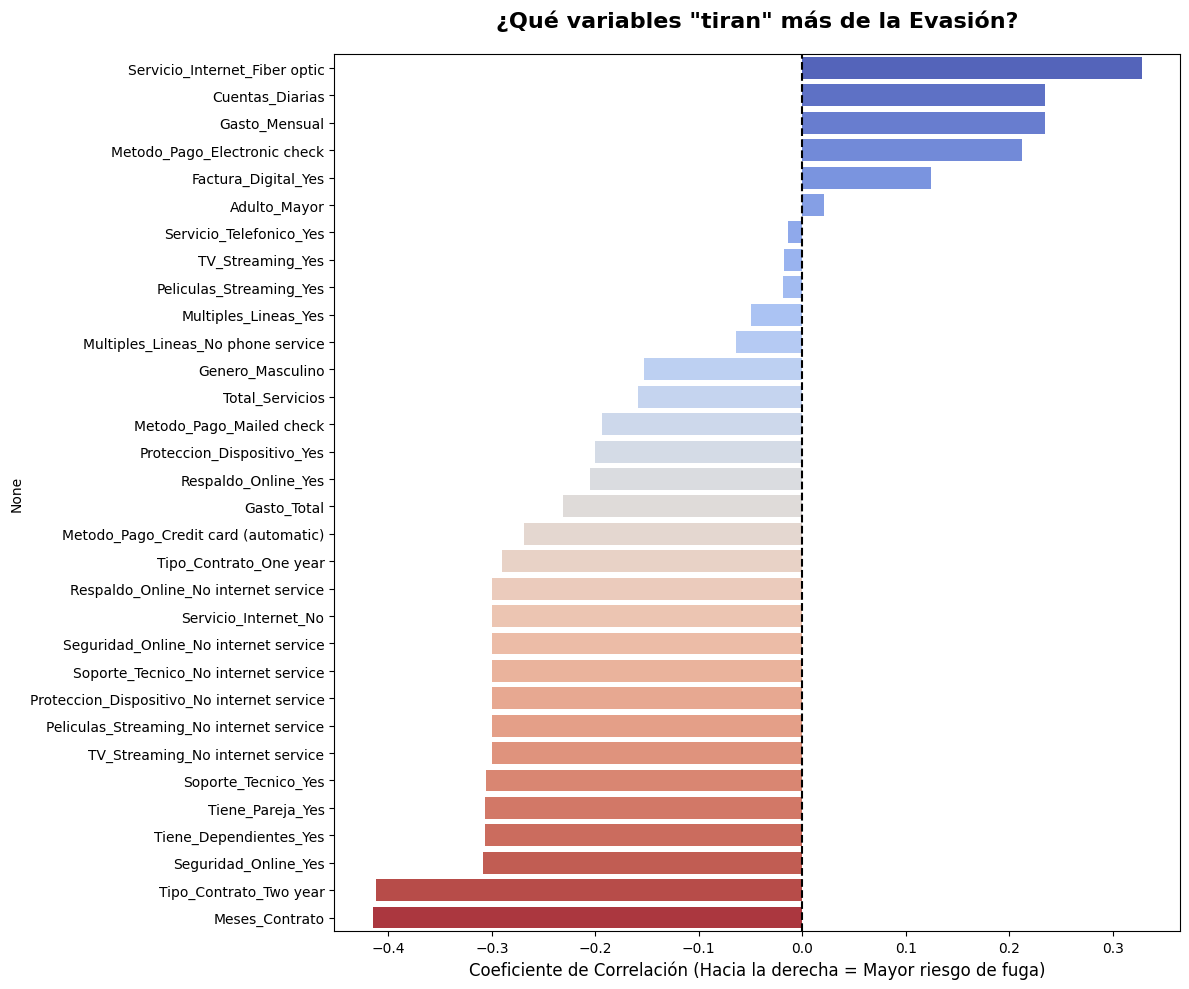

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Unimos temporalmente nuestras características (X) y el objetivo (y) para calcular la matemática
df_analisis = X_escalado.copy()
df_analisis['Evasion'] = y_balanceado.values

# 2. Calculamos la correlación de TODAS las columnas, pero nos quedamos solo con la columna 'Evasion'
correlacion = df_analisis.corr()['Evasion'].drop('Evasion').sort_values(ascending=False)

# 3. Armamos un gráfico de barras horizontal (ideal para leer nombres largos)
plt.figure(figsize=(12, 10))
# palette='coolwarm' pinta de rojo las correlaciones positivas y de azul las negativas
sns.barplot(x=correlacion.values, y=correlacion.index, palette='coolwarm')

# 4. Detalles estéticos para presentarlo en la agencia
plt.title('¿Qué variables "tiran" más de la Evasión?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Coeficiente de Correlación (Hacia la derecha = Mayor riesgo de fuga)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

/tmp/ipykernel_395/2004747764.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_modelos, x='Evasion', y='Meses_Contrato', ax=axes[0], palette='Set2')
/tmp/ipykernel_395/2004747764.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_modelos, x='Evasion', y='Gasto_Total', ax=axes[1], palette='Set1')


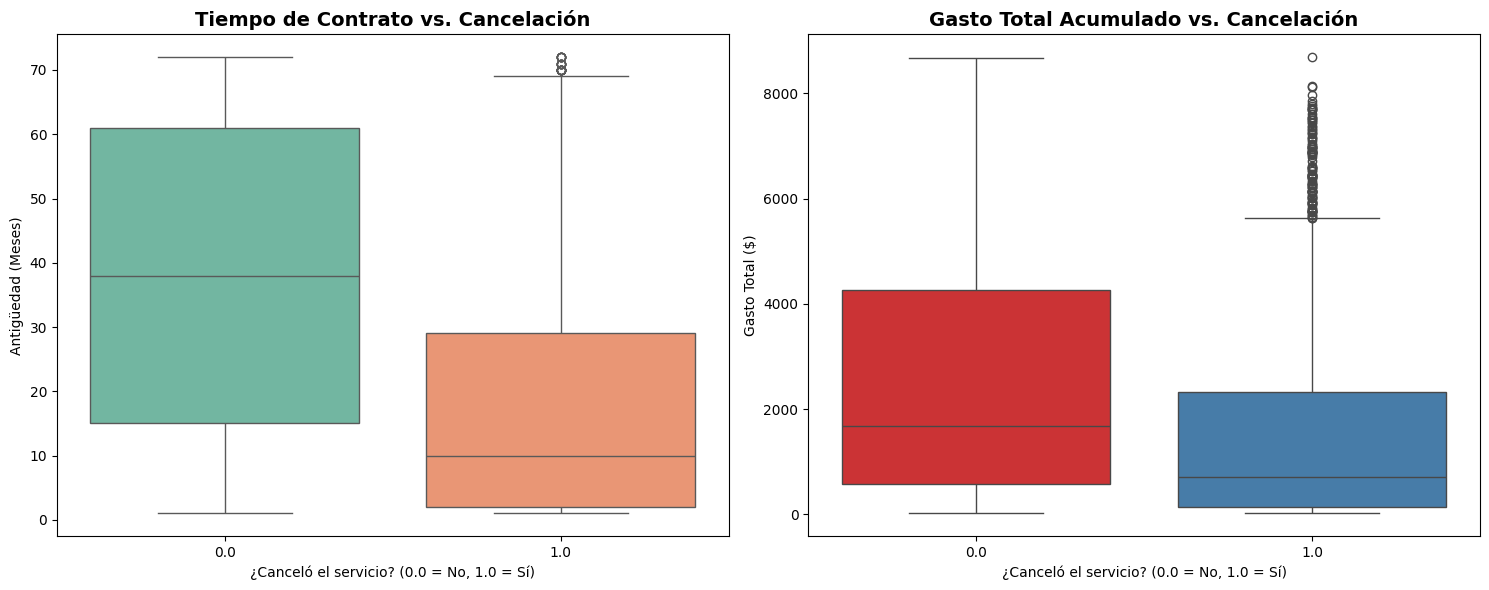

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuramos el lienzo para poner dos gráficos en paralelo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Gráfico A: Tiempo de Contrato vs Cancelación
sns.boxplot(data=df_modelos, x='Evasion', y='Meses_Contrato', ax=axes[0], palette='Set2')
axes[0].set_title('Tiempo de Contrato vs. Cancelación', fontsize=14, fontweight='bold')
axes[0].set_xlabel('¿Canceló el servicio? (0.0 = No, 1.0 = Sí)')
axes[0].set_ylabel('Antigüedad (Meses)')

# 3. Gráfico B: Gasto Total vs Cancelación
sns.boxplot(data=df_modelos, x='Evasion', y='Gasto_Total', ax=axes[1], palette='Set1')
axes[1].set_title('Gasto Total Acumulado vs. Cancelación', fontsize=14, fontweight='bold')
axes[1].set_xlabel('¿Canceló el servicio? (0.0 = No, 1.0 = Sí)')
axes[1].set_ylabel('Gasto Total ($)')

# 4. Ajustamos los espacios y mostramos
plt.tight_layout()
plt.show()

# 🤖 Modelado Predictivo

In [14]:
from sklearn.model_selection import train_test_split

# 1. Dividimos los datos (70% Entrenamiento / 30% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X_escalado,
    y_balanceado,
    test_size=0.3,
    random_state=42,
    stratify=y_balanceado
)

# 2. Imprimimos el resultado para confirmar que la tijera cortó bien
print("--- ✂️ DIVISIÓN DE DATOS (TRAIN / TEST) ---")
print(f"📚 Datos para que el modelo ESTUDIE (Train): {X_train.shape[0]} clientes")
print(f"📝 Datos para el EXAMEN FINAL (Test): {X_test.shape[0]} clientes")
print(f"\nTotal sumado: {X_escalado.shape[0]} clientes (¡Todo cuadra!)")

--- ✂️ DIVISIÓN DE DATOS (TRAIN / TEST) ---
📚 Datos para que el modelo ESTUDIE (Train): 7228 clientes
📝 Datos para el EXAMEN FINAL (Test): 3098 clientes

Total sumado: 10326 clientes (¡Todo cuadra!)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- 1. ENTRENAMOS LA REGRESIÓN LOGÍSTICA ---
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train, y_train) # Acá el modelo "estudia"

# Le pedimos que rinda el examen final con los datos que no conoce
predicciones_lr = modelo_lr.predict(X_test)


# --- 2. ENTRENAMOS EL RANDOM FOREST ---
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train) # Acá el bosque "estudia"

# Rinde el examen final
predicciones_rf = modelo_rf.predict(X_test)

print("✅ ¡Entrenamiento completado!")
print("Los dos modelos ya estudiaron los datos (Train) y rindieron su examen (Test).")

✅ ¡Entrenamiento completado!
Los dos modelos ya estudiaron los datos (Train) y rindieron su examen (Test).


--- 📊 NOTAS DEL MODELO: REGRESIÓN LOGÍSTICA ---
Exactitud (Test):  0.8302  |  (Train: 0.8373) <- Ojo acá
Precisión:         0.8207
Recall:            0.8451
F1-Score:          0.8327

--- 📊 NOTAS DEL MODELO: RANDOM FOREST ---
Exactitud (Test):  0.8415  |  (Train: 0.9990) <- Ojo acá
Precisión:         0.8233
Recall:            0.8696
F1-Score:          0.8458



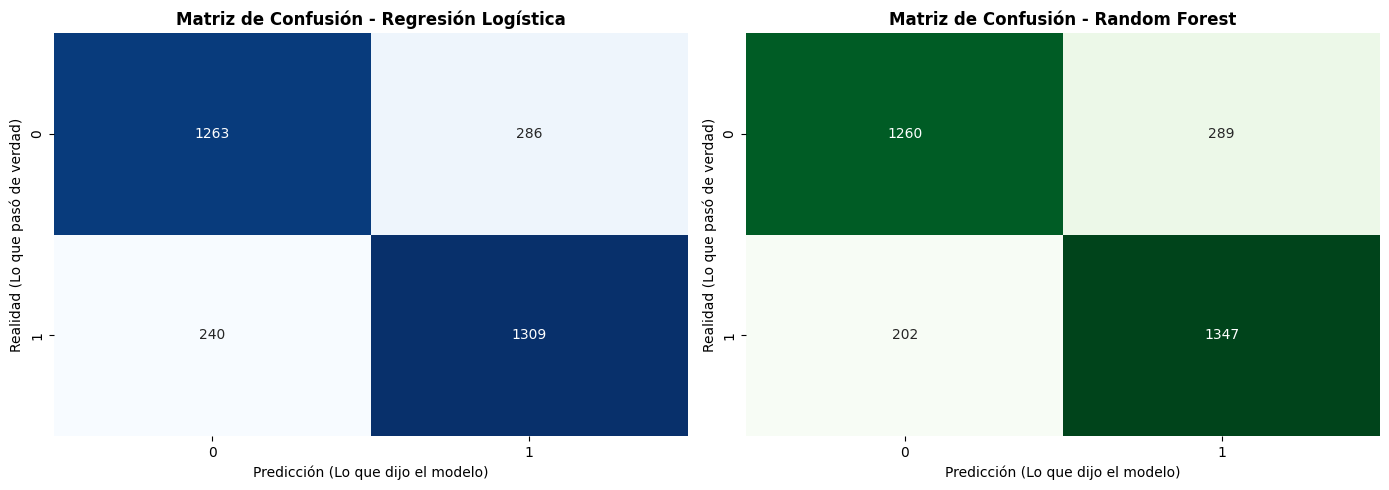

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Función automatizada para calcular y mostrar todas las métricas
def evaluar_y_reportar(nombre, y_real, y_pred, modelo, X_train, y_train):
    # Calculamos métricas sobre el examen final (Test)
    acc = accuracy_score(y_real, y_pred)
    prec = precision_score(y_real, y_pred)
    rec = recall_score(y_real, y_pred)
    f1 = f1_score(y_real, y_pred)

    # Calculamos la exactitud en el set de estudio (Train) para detectar Overfitting
    y_pred_train = modelo.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)

    print(f"--- 📊 NOTAS DEL MODELO: {nombre} ---")
    print(f"Exactitud (Test):  {acc:.4f}  |  (Train: {acc_train:.4f}) <- Ojo acá")
    print(f"Precisión:         {prec:.4f}")
    print(f"Recall:            {rec:.4f}")
    print(f"F1-Score:          {f1:.4f}\n")

    return confusion_matrix(y_real, y_pred)

# 2. Ejecutamos la evaluación
cm_lr = evaluar_y_reportar("REGRESIÓN LOGÍSTICA", y_test, predicciones_lr, modelo_lr, X_train, y_train)
cm_rf = evaluar_y_reportar("RANDOM FOREST", y_test, predicciones_rf, modelo_rf, X_train, y_train)

# 3. Dibujamos las Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz 1: Regresión Logística
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de Confusión - Regresión Logística', fontweight='bold')
axes[0].set_xlabel('Predicción (Lo que dijo el modelo)')
axes[0].set_ylabel('Realidad (Lo que pasó de verdad)')

# Matriz 2: Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión - Random Forest', fontweight='bold')
axes[1].set_xlabel('Predicción (Lo que dijo el modelo)')
axes[1].set_ylabel('Realidad (Lo que pasó de verdad)')

plt.tight_layout()
plt.show()

# 📋 Interpretación y Conclusiones

/tmp/ipykernel_395/2721269367.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_lr, x='Coeficiente', y='Variable', ax=axes[0], palette='coolwarm')
/tmp/ipykernel_395/2721269367.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp_rf, x='Importancia', y='Variable', ax=axes[1], palette='viridis')


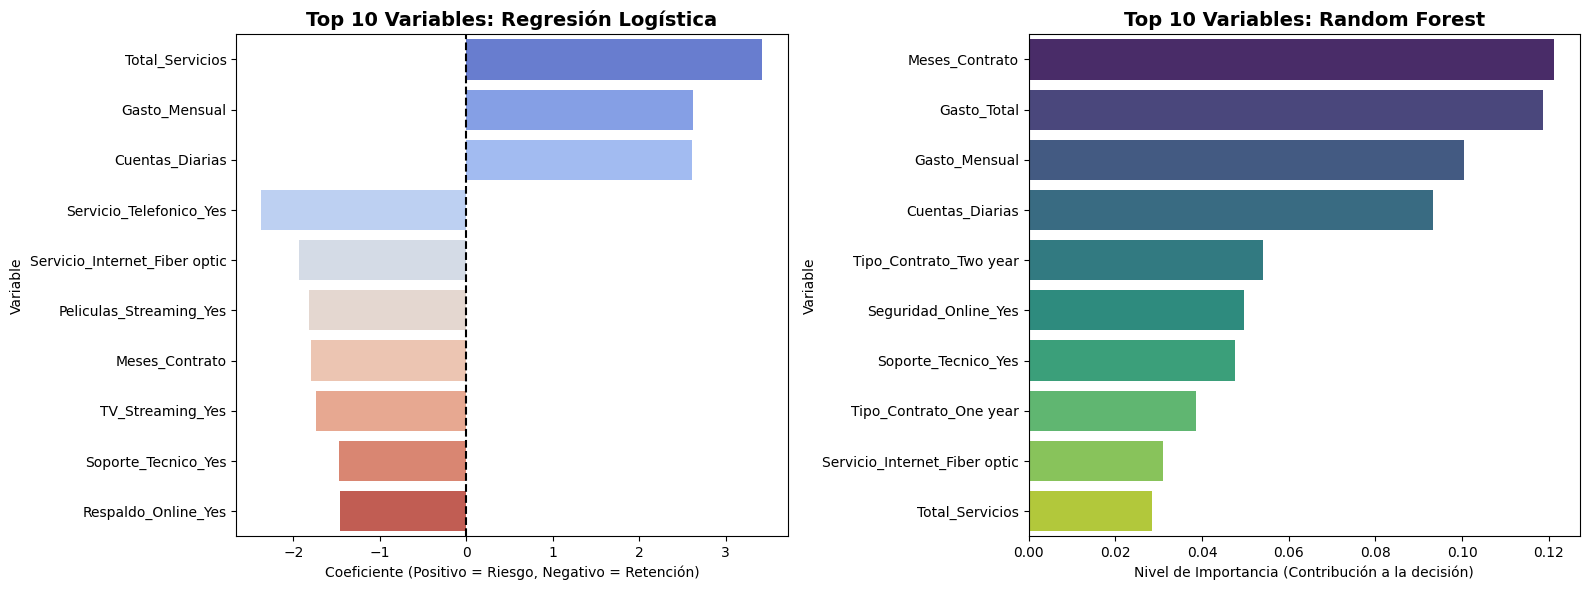

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperamos los nombres de las columnas que usamos para entrenar
variables = X_train.columns

# --- A. ANÁLISIS DE REGRESIÓN LOGÍSTICA (Coeficientes) ---
coeficientes_lr = modelo_lr.coef_[0]
df_imp_lr = pd.DataFrame({'Variable': variables, 'Coeficiente': coeficientes_lr})
df_imp_lr = df_imp_lr.sort_values(by='Coeficiente', key=abs, ascending=False).head(10)

# --- B. ANÁLISIS DE RANDOM FOREST (Feature Importances) ---
importancia_rf = modelo_rf.feature_importances_
df_imp_rf = pd.DataFrame({'Variable': variables, 'Importancia': importancia_rf})
df_imp_rf = df_imp_rf.sort_values(by='Importancia', ascending=False).head(10)

# 2. Preparamos el lienzo para los dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Regresión Logística
# Usamos coolwarm para ver los que "empujan a irse" en rojo y los que "retienen" en azul
sns.barplot(data=df_imp_lr, x='Coeficiente', y='Variable', ax=axes[0], palette='coolwarm')
axes[0].set_title('Top 10 Variables: Regresión Logística', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Coeficiente (Positivo = Riesgo, Negativo = Retención)')
axes[0].axvline(x=0, color='black', linestyle='--') # Línea del cero

# Gráfico de Random Forest
sns.barplot(data=df_imp_rf, x='Importancia', y='Variable', ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Variables: Random Forest', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nivel de Importancia (Contribución a la decisión)')

plt.tight_layout()
plt.show()

# 🧠 Predicción de Cancelación (Churn) con Machine Learning - Telecom X
## 🎯 1. Resumen del Proyecto
Tras la fase de análisis exploratorio, el objetivo de esta segunda etapa fue construir un pipeline de Machine Learning capaz de predecir qué clientes tienen mayor probabilidad de abandonar Telecom X. Se implementaron técnicas de preprocesamiento avanzado (One-Hot Encoding, Estandarización) y balanceo de clases (SMOTE) para entrenar modelos predictivos robustos.

## 🤖 2. Evaluación de Modelos
Se entrenaron y compararon dos algoritmos principales:

Regresión Logística: Demostró ser un modelo estable y generalizó bien los datos, aunque su capacidad para detectar clientes en riesgo (Sensibilidad/Recall) fue ligeramente inferior.

Random Forest (Bosque Aleatorio): Fue el modelo ganador. Logró identificar correctamente a 1347 clientes en riesgo (Verdaderos Positivos), superando a la regresión. Aunque presentó cierta tendencia al sobreajuste (overfitting) en los datos de entrenamiento, su capacidad predictiva en el entorno de prueba fue superior y más útil para los objetivos del negocio.

## 📊 3. Factores Críticos de Cancelación (Insights)
El análisis de importancia de variables del Random Forest reveló que la decisión de cancelar no es aleatoria, sino que está impulsada por tres ejes fundamentales:

El Factor Tiempo (Meses_Contrato): Es la variable número 1 indiscutible. La lealtad se construye con el tiempo; el riesgo de fuga se concentra drásticamente en los primeros meses de vida del cliente.

El Factor Económico (Gasto_Total y Gasto_Mensual): El peso de la factura es el segundo motor de cancelación. Los clientes están evaluando constantemente si el servicio justifica el precio que pagan mes a mes.

El Escudo del Contrato (Tipo_Contrato_Two_year y One_year): Tener contratos a largo plazo actúa como una barrera de salida fortísima, apareciendo en el top 5 de variables que definen el comportamiento del usuario.

## 💡 4. Estrategias de Retención Propuestas
Desde una visión enfocada en la optimización operativa y la rentabilidad, se sugieren las siguientes acciones inmediatas para Telecom X:

Estrategia de "Aterrizaje Seguro" (Onboarding): Dado que la antigüedad es el factor de retención más fuerte, se debe invertir fuertemente en la experiencia del usuario durante los primeros 6 meses. Sugiero implementar descuentos escalonados o beneficios exclusivos que se desbloqueen al cumplir el primer año.

Migración de Contratos: El modelo demuestra que los contratos a 1 o 2 años "atan" positivamente al cliente. El equipo de marketing debe lanzar campañas agresivas para convertir a los clientes "Mes a Mes" en clientes anuales, quizás absorbiendo el costo de instalación o regalando meses de servicio.

Auditoría de Percepción de Valor: Como el gasto mensual alto dispara las alertas del algoritmo, Telecom X debe asegurar que sus clientes VIP (los que más pagan) reciban atención prioritaria y servicios de valor agregado (Soporte_Tecnico, Seguridad_Online) sin costo extra, para que no busquen alternativas más económicas en la competencia.